# 寻找价格预测异常日

## 提取4月日前、实时电价

In [9]:
import pandas as pd

file_paths = [f'/Users/huyang/Desktop/2026年4月可视化图表/江苏现货价格可视化图表202604{i:02d}.xlsx' for i in range(1, 31)]
all_dfs = []

for i, file_path in enumerate(file_paths, start=1):
    df = pd.read_excel(
        file_path,
        sheet_name='日前、实时价格',
        usecols='B,C,J',
        skiprows=2,  # 跳过前2行
        header=None   # 不将任何行作为列名，因为数据从第3行开始
    )
    df.columns = ['时刻','日前电价(元/MWh)','实时电价(元/MWh)']
    	
    # 删除全为空值的行
    df = df.dropna(how='all', subset=['日前电价(元/MWh)', '实时电价(元/MWh)'])

    # 将最后一个时刻改为'24:00'
    if not df.empty:
        df.iloc[-1, df.columns.get_loc('时刻')] = '00:00:00'
    
    # 设置多层索引（表号, 时刻）
    df['日期'] = f'2026/04/{i:02d}'
    df.set_index(['日期', '时刻'], inplace=True)
    
    all_dfs.append(df)

result = pd.concat(all_dfs).sort_index()
result.to_excel('/Users/huyang/Desktop/4月电力价格/4月日前&实时电价.xlsx')
result

日前电价(元/MWh)  实时电价(元/MWh)
日期         时刻                                
2026/04/01 00:15:00        289.7        335.6
           00:30:00        319.0        335.7
           00:45:00        319.0        338.6
           01:00:00        319.2        341.3
           01:15:00        319.2        338.7
...                          ...          ...
2026/04/30 23:00:00        330.2        340.6
           23:15:00        331.9        344.6
           23:30:00        324.8        334.6
           23:45:00        337.3        339.7
           00:00:00        345.3        348.7

[2880 rows x 2 columns]

## 提取4月每小时日前、实时电价

In [34]:
import pandas as pd

file_paths = [f'/Users/huyang/Desktop/2026年4月可视化图表/江苏现货价格可视化图表202604{i:02d}.xlsx' for i in range(1, 31)]
all_dfs = []

for i, file_path in enumerate(file_paths, start=1):
    df = pd.read_excel(
        file_path,
        sheet_name='日前、实时价格',
        usecols='E,F,M',
        skiprows=2,
        header=None
    )
    df.columns = ['小时','日前电价(元/MWh)','实时电价(元/MWh)']
    
    # 删除全为空值的行
    df = df.dropna(how='all', subset=['小时'])
    
    # 添加日期列（普通列，不设索引）
    df['日期'] = f'2026/04/{i:02d}'
    
    # 调整列的顺序
    df = df[['日期', '小时', '日前电价(元/MWh)', '实时电价(元/MWh)']]
    
    all_dfs.append(df)

# 直接拼接，保持原始顺序
result = pd.concat(all_dfs, ignore_index=True)

# 保存时不带索引
result.to_excel('/Users/huyang/Desktop/4月电力价格/4月每小时日前&实时电价.xlsx', index=False)
result

,日期,小时,日前电价(元/MWh),实时电价(元/MWh)
0,2026/04/01,1时,311.725,337.800
1,2026/04/01,2时,319.100,338.300
2,2026/04/01,3时,324.775,346.525
3,2026/04/01,4时,321.725,341.675
4,2026/04/01,5时,320.000,340.900
...,...,...,...,...
715,2026/04/30,20时,361.000,333.175
716,2026/04/30,21时,343.825,329.750
717,2026/04/30,22时,326.400,325.750
718,2026/04/30,23时,330.275,337.650


## 绘制日前、实时电价波动折线图

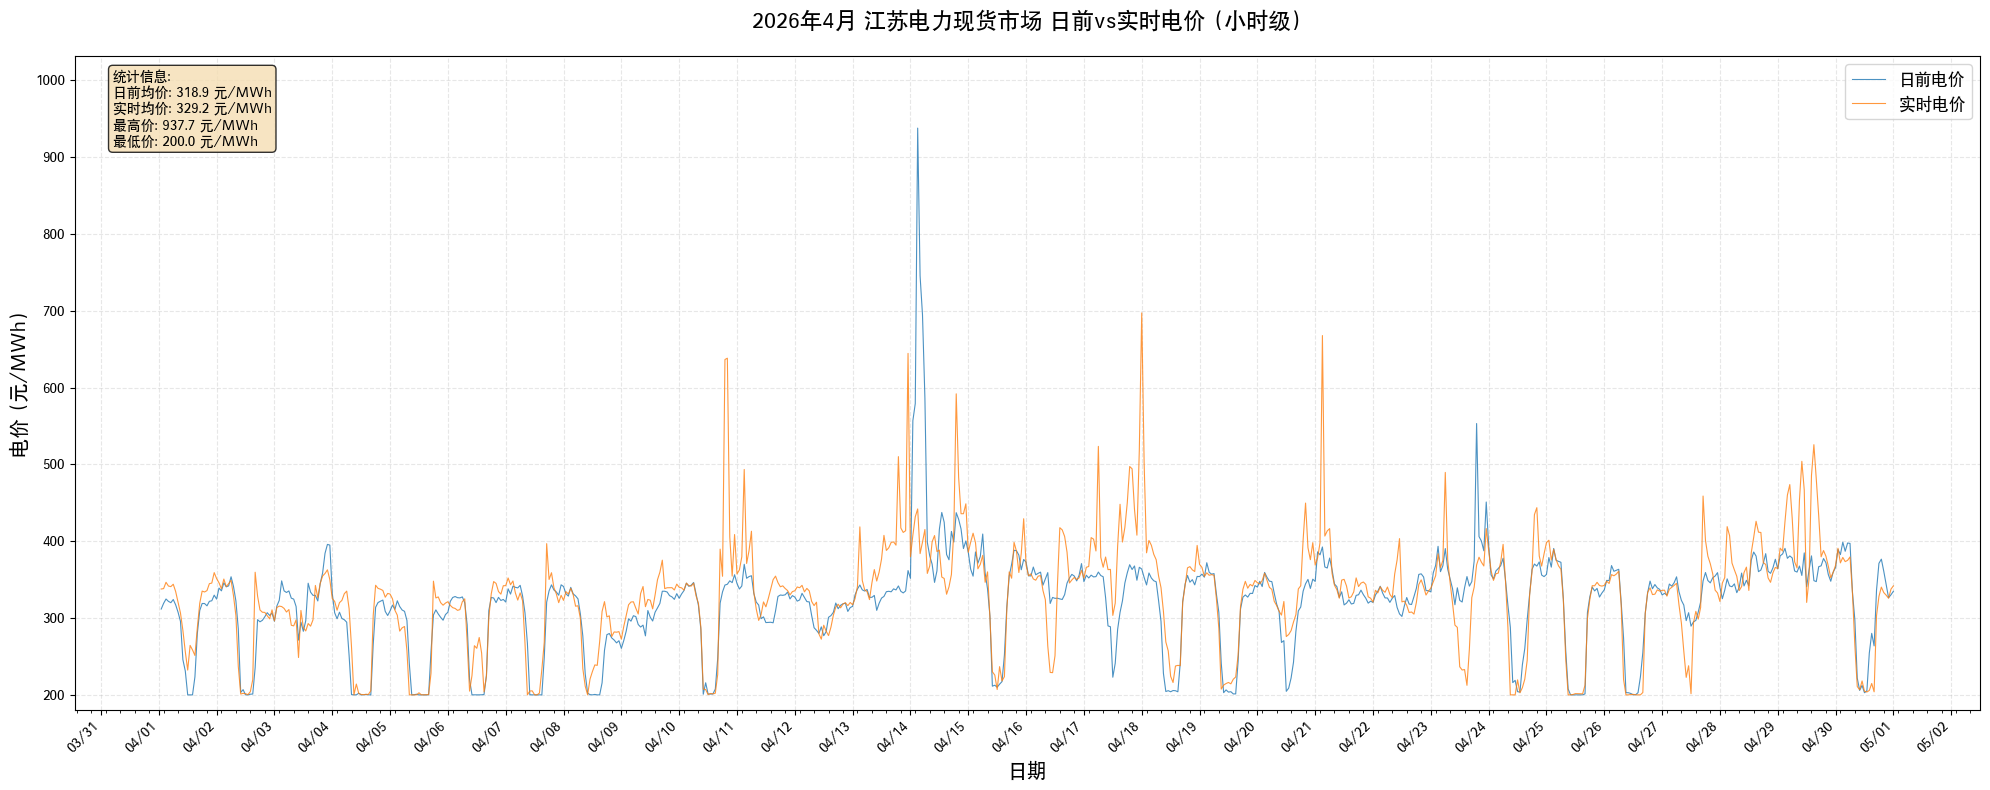

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# 读取数据
df = pd.read_excel('/Users/huyang/Desktop/4月电力价格/4月每小时日前&实时电价.xlsx')

# 创建datetime列用于绘图
def create_datetime(row):
    date_str = row['日期']
    hour_str = str(row['小时'])
    
    # 提取小时数字
    import re
    hour_num = int(re.findall(r'\d+', hour_str)[0])
    
    # 处理24时（即第二天的0点）
    if hour_num == 24:
        base_date = pd.to_datetime(date_str)
        return base_date + pd.Timedelta(days=1)
    else:
        # 构建时间字符串
        time_str = f"{date_str} {hour_num:02d}:00:00"
        return pd.to_datetime(time_str)

df['datetime'] = df.apply(create_datetime, axis=1)
df = df.sort_values('datetime')

# 绘制折线图
fig, ax = plt.subplots(figsize=(20, 8))

# 绘制两条价格曲线
ax.plot(df['datetime'], df['日前电价(元/MWh)'], 
        label='日前电价', linewidth=0.8, alpha=0.8, color='#1f77b4')
ax.plot(df['datetime'], df['实时电价(元/MWh)'], 
        label='实时电价', linewidth=0.8, alpha=0.8, color='#ff7f0e')

# 设置图表格式
ax.set_xlabel('日期', fontsize=14, fontweight='bold')
ax.set_ylabel('电价 (元/MWh)', fontsize=14, fontweight='bold')
ax.set_title('2026年4月 江苏电力现货市场 日前vs实时电价 (小时级)', 
            fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3, linestyle='--')

# 设置x轴格式
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))  # 每天一个刻度
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=6))  # 每6小时一个次刻度

# 旋转x轴标签
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 添加数据统计信息
avg_dayahead = df['日前电价(元/MWh)'].mean()
avg_realtime = df['实时电价(元/MWh)'].mean()
max_price = max(df['日前电价(元/MWh)'].max(), df['实时电价(元/MWh)'].max())
min_price = min(df['日前电价(元/MWh)'].min(), df['实时电价(元/MWh)'].min())

stats_text = f'统计信息:\n日前均价: {avg_dayahead:.1f} 元/MWh\n实时均价: {avg_realtime:.1f} 元/MWh\n最高价: {max_price:.1f} 元/MWh\n最低价: {min_price:.1f} 元/MWh'
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# 设置y轴范围，留一些空间
y_min = min_price * 0.9 if min_price > 0 else min_price * 1.1
y_max = max_price * 1.1
ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.savefig('/Users/huyang/Desktop/4月电力价格/4月电价波动图_小时级.png', 
             dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 找出每天24h总价差最大的异常日

In [31]:
import pandas as pd
import re

# 读取数据
df = pd.read_excel('/Users/huyang/Desktop/4月电力价格/4月每小时日前&实时电价.xlsx')

# 计算价差（绝对值）
df['价差(元/MWh)'] = abs(df['日前电价(元/MWh)'] - df['实时电价(元/MWh)'])

# 查看价差的整体分布
print("\n" + "=" * 70)
print("价差分布统计：")
print("=" * 70)
print(f"平均价差：{df['价差(元/MWh)'].mean():.2f} 元/MWh")
print(f"中位数价差：{df['价差(元/MWh)'].median():.2f} 元/MWh")
print(f"最大价差：{df['价差(元/MWh)'].max():.2f} 元/MWh")
print(f"价差超过100元/MWh的小时数：{(df['价差(元/MWh)'] > 100).sum()}")
print(f"价差超过200元/MWh的小时数：{(df['价差(元/MWh)'] > 200).sum()}")

# 按日期统计每日最大价差
print("\n" + "=" * 70)
print("每日最大价差 Top 5：")
print("=" * 70)
daily_max = df.groupby('日期')['价差(元/MWh)'].max().nlargest(5)
for date, gap in daily_max.items():
    print(f"  {date}：最大价差 {gap:.2f} 元/MWh")


价差分布统计：
平均价差：29.00 元/MWh
中位数价差：15.05 元/MWh
最大价差：495.70 元/MWh
价差超过100元/MWh的小时数：31
价差超过200元/MWh的小时数：8

每日最大价差 Top 5：
  2026/04/14：最大价差 495.70 元/MWh
  2026/04/17：最大价差 333.40 元/MWh
  2026/04/10：最大价差 294.28 元/MWh
  2026/04/13：最大价差 282.68 元/MWh
  2026/04/21：最大价差 275.20 元/MWh


# 分析异常成因

## 出力预测异常

# 提取出力占比

In [39]:
import pandas as pd

file_paths = [f'/Users/huyang/Desktop/2026年4月可视化图表/江苏现货价格可视化图表202604{i:02d}.xlsx' for i in range(1, 31)]
all_dfs = []

for i, file_path in enumerate(file_paths, start=1):
    df = pd.read_excel(
        file_path,
        sheet_name='电网运行信息',
        usecols='R,S,T,Z,AA,AB,AD,AT,AU,BA,BB,BC,BL',
        skiprows=2,  # 跳过前2行
        header=None   # 不将任何行作为列名，因为数据从第3行开始
    )
    
    # 统一列名
    df.columns = ['小时', '预测统调', '预测非气火电', '预测光伏','预测风电','预测新能源','预测受电',
                  '实际统调', '实际非气火电', '实际光伏','实际风电','实际新能源','实际受电']

    df.dropna(subset=['小时'], inplace=True)

     # 去除均值行
    # df = df[~df['时刻'].str.contains('均值|平均|avg', case=False, na=False)]
    
    # 设置多层索引（表号, 时刻）
    df['日期'] = f'2026/04/{i:02d}'
    df.set_index(['日期', '小时'], inplace=True)
    
    all_dfs.append(df)

result_df = pd.concat(all_dfs)

# 定义需要计算占比的发电类型
types = ['非气火电', '光伏', '风电', '新能源', '受电']

# 批量计算预测和实际的占比
for t in types:
    result_df[f'预测{t}占比'] = (result_df[f'预测{t}'] / result_df['预测统调'] * 100).round(2)
    result_df[f'实际{t}占比'] = (result_df[f'实际{t}'] / result_df['实际统调'] * 100).round(2)

result_df.to_excel('/Users/huyang/Desktop/4月电力价格/4月每小时各类出力情况.xlsx')
result_df

预测统调      预测非气火电    预测光伏        预测风电       预测新能源  \
日期         小时                                                          
2026/04/01 1时   81380.25  64279.9800  0.0000   3225.2700   3225.2700   
           2时   80061.50  65714.5750  0.0000   3323.4250   3323.4250   
           3时   82969.50  69362.6300  0.0000   3285.6200   3285.6200   
           4时   81783.00  68287.8500  0.0000   3223.4000   3223.4000   
           5时   81155.50  67822.5300  0.0000   3126.2200   3126.2200   
...                  ...         ...     ...         ...         ...   
2026/04/30 20时  86090.25  51597.5500  0.0175   5554.9325   5554.9500   
           21时  85039.00  48509.8050  0.0000   7611.9450   7611.9450   
           22时  83508.50  48242.5175  0.0000   9655.9825   9655.9825   
           23时  82333.50  52652.9400  0.0000  11755.0600  11755.0600   
           24时  78640.50  50603.5700  0.0000  13645.6800  13645.6800   

                    预测受电       实际统调       实际非气火电    实际光伏        实际风电  ...  \
日期         小时                                                         ...   
2026/04/01 1时   11257.00  82120.775  66019.83125  7.5875   1934.0225  ...   
           2时    8405.50  80628.475  64958.20025  7.5250   2050.5150  ...   
           3时    7703.25  83092.925  67534.74200  7.6450   2045.3575  ...   
           4时    7651.50  81910.850  66206.15400  7.4150   2124.3275  ...   
           5时    7588.75  81590.400  65922.44250  7.6525   1815.6850  ...   
...                  ...        ...          ...     ...         ...  ...   
2026/04/30 20时  20919.50  85276.575  51932.34475  6.2200   4192.2125  ...   
           21时  20725.25  84509.600  49740.04275  7.2375   5744.9225  ...   
           22时  18588.50  83297.675  49760.09000  6.8750   7457.7075  ...   
           23时  14938.00  83058.700  54064.27250  7.0650   9007.7875  ...   
           24时  12305.25  79245.700  54387.30450  7.1225  10598.0000  ...   

                预测非气火电占比  实际非气火电占比  预测光伏占比  实际光伏占比  预测风电占比  实际风电占比  预测新能源占比  \
日期         小时                                                                 
2026/04/01 1时      78.99     80.39     0.0    0.01    3.96    2.36     3.96   
           2时      82.08     80.56     0.0    0.01    4.15    2.54     4.15   
           3时      83.60     81.28     0.0    0.01    3.96    2.46     3.96   
           4时      83.50     80.83     0.0    0.01    3.94    2.59     3.94   
           5时      83.57     80.80     0.0    0.01    3.85    2.23     3.85   
...                  ...       ...     ...     ...     ...     ...      ...   
2026/04/30 20时     59.93     60.90     0.0    0.01    6.45    4.92     6.45   
           21时     57.04     58.86     0.0    0.01    8.95    6.80     8.95   
           22时     57.77     59.74     0.0    0.01   11.56    8.95    11.56   
           23时     63.95     65.09     0.0    0.01   14.28   10.85    14.28   
           24时     64.35     68.63     0.0    0.01   17.35   13.37    17.35   

                实际新能源占比  预测受电占比  实际受电占比  
日期         小时                            
2026/04/01 1时      2.36   13.83   14.03  
           2时      2.55   10.50   13.66  
           3时      2.47    9.28   13.20  
           4时      2.60    9.36   13.41  
           5时      2.23    9.35   13.78  
...                 ...     ...     ...  
2026/04/30 20时     4.92   24.30   24.62  
           21时     6.81   24.37   24.91  
           22时     8.96   22.26   23.33  
           23时    10.85   18.14   20.61  
           24时    13.38   15.65   15.60  

[720 rows x 22 columns]

# 价格与新能源出力的关系

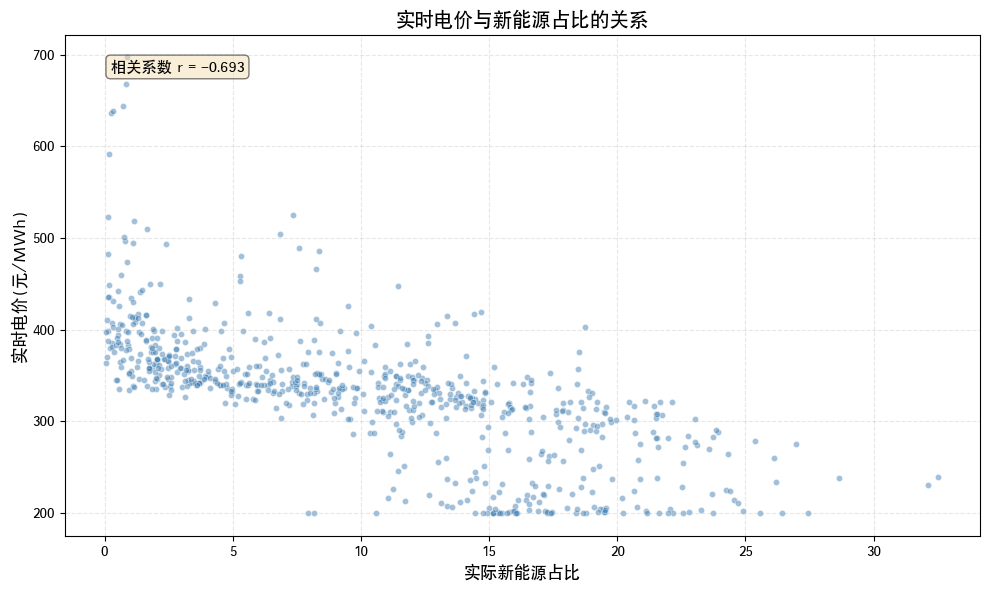

In [41]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Hei']
plt.rcParams['axes.unicode_minus'] = False

price = pd.read_excel('/Users/huyang/Desktop/4月电力价格/4月每小时日前&实时电价.xlsx')
df = pd.read_excel('/Users/huyang/Desktop/4月电力价格/4月每小时各类出力情况.xlsx')
save_path = '/Users/huyang/Desktop/4月电力价格/'

plt.figure(figsize=(10, 6))
plt.scatter(df['实际新能源占比'],price['实时电价(元/MWh)'], 
            alpha=0.5,        # 透明度
            s=20,             # 点的大小
            c='steelblue',    # 颜色
            edgecolors='white',  # 边缘白色
            linewidth=0.5)
   
# 添加标签和标题
plt.xlabel('实际新能源占比', fontsize=12)
plt.ylabel('实时电价(元/MWh)', fontsize=12)
plt.title('实时电价与新能源占比的关系', fontsize=14, fontweight='bold')
# 添加网格
plt.grid(True, alpha=0.3, linestyle='--')
# 显示相关系数
correlation = df['实际新能源占比'].corr(price['实时电价(元/MWh)'])
plt.text(0.05, 0.95, f'相关系数 r = {correlation:.3f}', 
        transform=plt.gca().transAxes, fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))


plt.tight_layout()
plt.savefig(f'{save_path}' + '实时电价与新能源占比的关系.png', dpi=150, bbox_inches='tight')
plt.show()

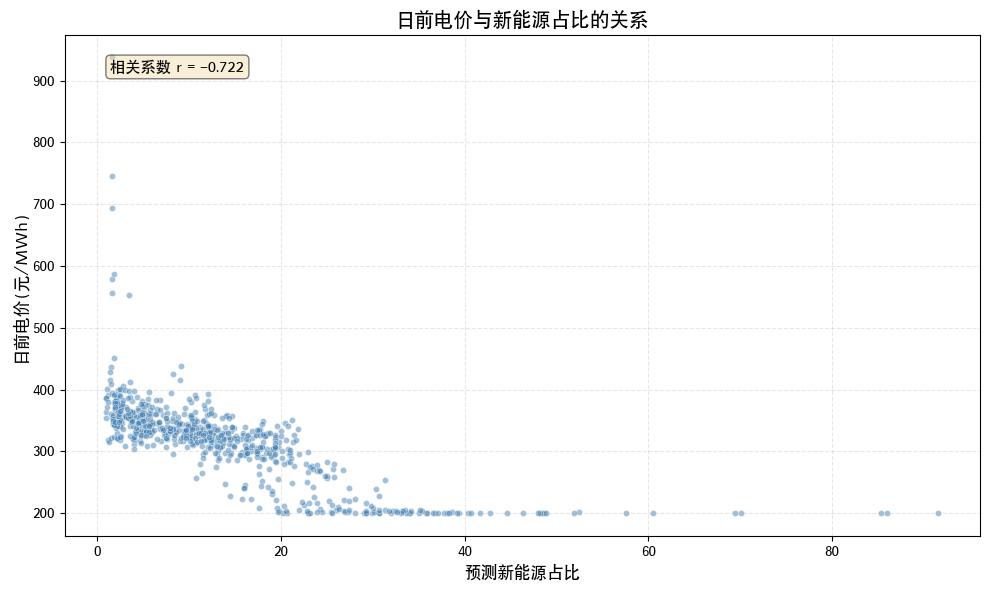

In [43]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Hei']
plt.rcParams['axes.unicode_minus'] = False

price = pd.read_excel('/Users/huyang/Desktop/4月电力价格/4月每小时日前&实时电价.xlsx')
df = pd.read_excel('/Users/huyang/Desktop/4月电力价格/4月每小时各类出力情况.xlsx')
save_path = '/Users/huyang/Desktop/4月电力价格/'

plt.figure(figsize=(10, 6))
plt.scatter(df['预测新能源占比'],price['日前电价(元/MWh)'], 
            alpha=0.5,        # 透明度
            s=20,             # 点的大小
            c='steelblue',    # 颜色
            edgecolors='white',  # 边缘白色
            linewidth=0.5)
   
# 添加标签和标题
plt.xlabel('预测新能源占比', fontsize=12)
plt.ylabel('日前电价(元/MWh)', fontsize=12)
plt.title('日前电价与新能源占比的关系', fontsize=14, fontweight='bold')
# 添加网格
plt.grid(True, alpha=0.3, linestyle='--')
# 显示相关系数
correlation = df['预测新能源占比'].corr(price['日前电价(元/MWh)'])
plt.text(0.05, 0.95, f'相关系数 r = {correlation:.3f}', 
        transform=plt.gca().transAxes, fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))


plt.tight_layout()
plt.savefig(f'{save_path}' + '日前电价与新能源占比的关系.png', dpi=150, bbox_inches='tight')
plt.show()